# C题结果解读与CSV指标复现实验

本 notebook 用于说明三类内容：

1. 多无人机起点如何用 K-means 思路选出来。
2. 问题一、问题二测试 CSV 中各项指标的含义，以及这些指标如何从结果表复现出来。
3. 如何从最终解中还原每次完整飞行任务，查看任务数、无人机编号、能量利用率和路径追踪。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "scripts" / "c_problem"))

from load_c_data import WORKBOOK_PATH, load_c_problem_data, parameter_value

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

print("Workspace root:", ROOT)
print("Workbook path:", ROOT / WORKBOOK_PATH)

Workspace root: D:\vscodings\shuxuejianmo
Workbook path: D:\vscodings\shuxuejianmo\2026同济数学建模竞赛赛题\2026C数据.xlsx


## 1. 读取实验输出与测试 CSV

这里统一读取问题一汇总表、问题一路线任务表、问题一路径明细表，以及问题二 F 引导对比表。先做文件存在性、字段、类型和缺失值检查。

In [2]:
summary_path = ROOT / "outputs" / "tables" / "c_problem_problem1_heuristic_summary.csv"
route_summary_path = ROOT / "outputs" / "tables" / "c_problem_problem1_route_summary.csv"
route_detail_path = ROOT / "data" / "processed" / "c_problem_problem1_route_detail.csv"
problem2_compare_path = ROOT / "outputs" / "tables" / "c_problem_problem2_f_guidance_compare.csv"

paths = {
    "problem1_summary": summary_path,
    "problem1_route_summary": route_summary_path,
    "problem1_route_detail": route_detail_path,
    "problem2_f_compare": problem2_compare_path,
}

for name, path in paths.items():
    print(f"{name}: {path.exists()} -> {path}")

problem1_summary = pd.read_csv(summary_path, encoding="utf-8-sig")
problem1_route_summary = pd.read_csv(route_summary_path, encoding="utf-8-sig")
problem1_route_detail = pd.read_csv(route_detail_path, encoding="utf-8-sig")
problem2_f_compare = pd.read_csv(problem2_compare_path, encoding="utf-8-sig")

loaded = {
    "problem1_summary": problem1_summary,
    "problem1_route_summary": problem1_route_summary,
    "problem1_route_detail": problem1_route_detail,
    "problem2_f_compare": problem2_f_compare,
}

for name, frame in loaded.items():
    print(f"\n{name}")
    print("shape:", frame.shape)
    display(pd.DataFrame({"dtype": frame.dtypes.astype(str), "missing": frame.isna().sum()}))
    display(frame.head())

problem1_summary: True -> D:\vscodings\shuxuejianmo\outputs\tables\c_problem_problem1_heuristic_summary.csv
problem1_route_summary: True -> D:\vscodings\shuxuejianmo\outputs\tables\c_problem_problem1_route_summary.csv
problem1_route_detail: True -> D:\vscodings\shuxuejianmo\data\processed\c_problem_problem1_route_detail.csv
problem2_f_compare: True -> D:\vscodings\shuxuejianmo\outputs\tables\c_problem_problem2_f_guidance_compare.csv

problem1_summary
shape: (4, 13)


,dtype,missing
drone_count,int64,0
construct_mode,str,0
target_count,int64,0
route_count,int64,0
makespan_s,float64,0
makespan_min,float64,0
total_hover_time_s,float64,0
total_flight_energy_j,float64,0
total_energy_j,float64,0
max_drone_time_s,float64,0


,drone_count,construct_mode,target_count,route_count,makespan_s,makespan_min,total_hover_time_s,total_flight_energy_j,total_energy_j,max_drone_time_s,load_std_s,feasible_within_horizon,horizon_s
0,1,f_guided,16,2,1312.167958,21.869466,790.0,37013.255750,210813.255750,1312.167958,0.000000,True,2600.0
1,2,f_guided,16,2,537.386401,8.956440,790.0,46124.121474,219924.121474,537.386401,8.941650,True,2600.0
2,3,f_guided,16,3,361.299422,6.021657,790.0,46207.775593,220007.775593,361.299422,6.839278,True,2600.0
3,4,f_guided,16,4,322.427812,5.373797,790.0,59853.317999,233653.317999,322.427812,23.085981,True,2600.0



problem1_route_summary
shape: (11, 17)


,dtype,missing
drone_count,int64,0
drone_id,int64,0
route_id,int64,0
route_order,int64,0
flight_task_count,int64,0
stop_count,int64,0
start_node_id,int64,0
end_node_id,int64,0
route_duration_s,float64,0
route_duration_min,float64,0


...

,dtype,missing
drone_count,int64,0
drone_id,int64,0
route_id,int64,0
route_order,int64,0
stop_order,int64,0
node_id,int64,0
hover_time_s,float64,0
route_duration_s,float64,0
route_energy_j,float64,0
route_path,str,0


,drone_count,drone_id,route_id,route_order,stop_order,node_id,hover_time_s,route_duration_s,route_energy_j,route_path,drone_total_time_s
0,1,1,1,1,1,13,60.0,625.195491,130756.707226,0-13-1-2-3-5-8-7-4-6-10-0,1312.167958
1,1,1,1,1,2,1,50.0,625.195491,130756.707226,0-13-1-2-3-5-8-7-4-6-10-0,1312.167958
2,1,1,1,1,3,2,60.0,625.195491,130756.707226,0-13-1-2-3-5-8-7-4-6-10-0,1312.167958
3,1,1,1,1,4,3,35.0,625.195491,130756.707226,0-13-1-2-3-5-8-7-4-6-10-0,1312.167958
4,1,1,1,1,5,5,50.0,625.195491,130756.707226,0-13-1-2-3-5-8-7-4-6-10-0,1312.167958



problem2_f_compare
shape: (2, 11)


,dtype,missing
drone_count,int64,0
baseline_s,float64,0
f_default_s,float64,0
f_default_direct_confirm_count,int64,0
f_ga_s,float64,0
f_ga_direct_confirm_count,int64,0
f_pso_s,float64,0
f_pso_direct_confirm_count,int64,0
f_aco_s,float64,0
f_aco_direct_confirm_count,int64,0


,drone_count,baseline_s,f_default_s,f_default_direct_confirm_count,f_ga_s,f_ga_direct_confirm_count,f_pso_s,f_pso_direct_confirm_count,f_aco_s,f_aco_direct_confirm_count,best_algorithm
0,3,4606.697652,4180.758936,4,3982.473785,5,3982.473785,5,3946.608072,5,ACO
1,4,4511.906167,3534.531428,7,3534.531428,7,3534.531428,7,3534.531428,7,GA


## 2. 加载节点坐标并设定无人机数量 $K$

这里读取节点坐标、仓库点和系统参数。后面用同一组节点来做 K-means 聚类示意，并用同一个 $K$ 来查看完整飞行任务。

In [3]:
data = load_c_problem_data(ROOT / WORKBOOK_PATH)
energy_limit = float(parameter_value(data.params, "effective_energy_limit_J"))
horizon = float(parameter_value(data.params, "operating_horizon_s"))

nodes = data.nodes.copy()
target_nodes = nodes.loc[
    nodes["node_id"] != 0,
    ["node_id", "node_name", "x_m", "y_m", "z_m", "priority_weight", "base_hover_time_s"],
].copy()
K = 3
RANDOM_STATE = 0

print("K =", K)
print("energy_limit =", energy_limit)
print("horizon =", horizon)
display(target_nodes.head())

K = 3
energy_limit = 135000.0
horizon = 2600.0


,node_id,node_name,x_m,y_m,z_m,priority_weight,base_hover_time_s
1,1,B1-东立面裂缝,92,148,18,2,50
2,2,B1-屋顶积水,78,138,31,3,60
3,3,B1-消防连廊顶部,84,126,24,1,35
4,4,B2-空调支架锈蚀,158,68,20,2,55
5,5,B2-屋面排水口堵塞,146,82,34,3,50


## 3. 使用 K-means 对任务节点聚类

按照当前脚本中的新思路，把全部目标点按空间位置聚成 $K$ 类。这里使用 $(x, y, z)$ 作为特征矩阵。

In [4]:
features = target_nodes[["x_m", "y_m", "z_m"]].astype(float)
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
target_nodes = target_nodes.copy()
target_nodes["cluster_id"] = kmeans.fit_predict(features)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=["x_m", "y_m", "z_m"])
centers["cluster_id"] = centers.index

display(centers)
display(target_nodes.sort_values(["cluster_id", "node_id"]))

,x_m,y_m,z_m,cluster_id
0,-13.50,-135.50,21.000,0
1,-176.50,110.50,24.500,1
2,141.25,69.75,25.125,2


,node_id,node_name,x_m,y_m,z_m,priority_weight,base_hover_time_s,cluster_id
9,9,B4-南外墙脱落点,46,-128,17,3,55,0
10,10,B4-屋顶天沟堆积,56,-116,30,2,45,0
11,11,B5-屋顶消防标识遮挡,-84,-154,25,1,35,0
12,12,B5-东侧外挂线缆,-72,-144,12,2,40,0
13,13,B6-屋顶空调机组异常,-148,46,24,3,60,1
14,14,B6-西立面渗水痕迹,-162,58,18,2,50,1
15,15,B7-光伏棚支架松动,-204,162,22,2,45,1
16,16,B7-屋顶围挡破损,-192,176,34,3,65,1
1,1,B1-东立面裂缝,92,148,18,2,50,2
2,2,B1-屋顶积水,78,138,31,3,60,2


## 4. 为每个簇选择最接近质心的起点

每个簇内选择一个最靠近质心的节点，作为该簇对应无人机的优先起点。这个逻辑与问题一脚本中的 K-means 起点候选顺序保持一致。

In [5]:
cluster_start_rows = []
for cluster_id, cluster_frame in target_nodes.groupby("cluster_id"):
    center = centers.loc[centers["cluster_id"] == cluster_id, ["x_m", "y_m", "z_m"]].iloc[0]
    scored = cluster_frame.copy()
    scored["centroid_distance_sq"] = (
        (scored["x_m"] - float(center["x_m"])) ** 2
        + (scored["y_m"] - float(center["y_m"])) ** 2
        + (scored["z_m"] - float(center["z_m"])) ** 2
    )
    scored = scored.sort_values(["centroid_distance_sq", "priority_weight"], ascending=[True, False])
    cluster_start_rows.append(scored.iloc[0].copy())
    display(scored[["cluster_id", "node_id", "node_name", "centroid_distance_sq", "priority_weight"]])

cluster_starts = pd.DataFrame(cluster_start_rows).sort_values(["cluster_id", "node_id"]).reset_index(drop=True)
display(cluster_starts[["cluster_id", "node_id", "node_name", "x_m", "y_m", "z_m", "centroid_distance_sq"]])

,cluster_id,node_id,node_name,centroid_distance_sq,priority_weight
12,0,12,B5-东侧外挂线缆,3575.5,2
9,0,9,B4-南外墙脱落点,3612.5,3
10,0,10,B4-屋顶天沟堆积,5291.5,2
11,0,11,B5-屋顶消防标识遮挡,5328.5,1


,cluster_id,node_id,node_name,centroid_distance_sq,priority_weight
14,1,14,B6-西立面渗水痕迹,3008.75,2
15,1,15,B7-光伏棚支架松动,3414.75,2
16,1,16,B7-屋顶围挡破损,4620.75,3
13,1,13,B6-屋顶空调机组异常,4972.75,3


,cluster_id,node_id,node_name,centroid_distance_sq,priority_weight
5,2,5,B2-屋面排水口堵塞,251.390625,3
4,2,4,B2-空调支架锈蚀,309.890625,2
6,2,6,B2-北立面瓷砖鼓包,1276.890625,2
3,2,3,B1-消防连廊顶部,6442.890625,1
1,2,1,B1-东立面裂缝,8599.390625,2
2,2,2,B1-屋顶积水,8693.140625,3
8,2,8,B3-屋顶通信箱体,11318.890625,3
7,2,7,B3-西侧窗框松动,15385.390625,2


,cluster_id,node_id,node_name,x_m,y_m,z_m,centroid_distance_sq
0,0,12,B5-东侧外挂线缆,-72,-144,12,3575.500000
1,1,14,B6-西立面渗水痕迹,-162,58,18,3008.750000
2,2,5,B2-屋面排水口堵塞,146,82,34,251.390625


## 5. 可视化聚类结果、质心与起点分配

下面的散点图展示节点、簇中心和选出来的起点。这样能直观看到每个簇的起点是否靠近中心，从而减少一次任务中的绕行。

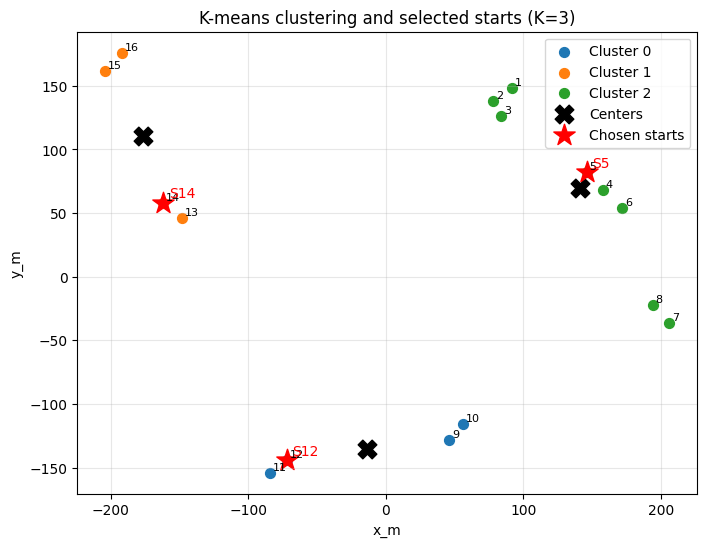

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id, cluster_frame in target_nodes.groupby("cluster_id"):
    ax.scatter(cluster_frame["x_m"], cluster_frame["y_m"], label=f"Cluster {cluster_id}", s=50)
    for row in cluster_frame.itertuples(index=False):
        ax.text(row.x_m + 2, row.y_m + 2, str(int(row.node_id)), fontsize=8)

ax.scatter(centers["x_m"], centers["y_m"], marker="X", s=180, c="black", label="Centers")
ax.scatter(cluster_starts["x_m"], cluster_starts["y_m"], marker="*", s=260, c="red", label="Chosen starts")
for row in cluster_starts.itertuples(index=False):
    ax.text(row.x_m + 4, row.y_m + 4, f"S{int(row.node_id)}", fontsize=10, color="red")

ax.set_title(f"K-means clustering and selected starts (K={K})")
ax.set_xlabel("x_m")
ax.set_ylabel("y_m")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 6. 解析测试 CSV 的字段、含义与来源

下面给出常用字段的说明。为了便于对照，按文件分成四类：问题一汇总表、飞行任务级表、路径明细表、问题二闭环对比表。

In [7]:
column_guide = pd.DataFrame([
    {"file": "problem1_summary", "column": "route_count", "unit": "条", "meaning": "该 K 下最终生成的完整飞行任务数", "formula": "按 route_id 计数"},
    {"file": "problem1_summary", "column": "makespan_s", "unit": "秒", "meaning": "所有无人机中最晚完成的时间", "formula": "max(drone_total_time_s)"},
    {"file": "problem1_summary", "column": "total_energy_j", "unit": "J", "meaning": "飞行与悬停合计能耗", "formula": "所有完整任务 route_energy_j 求和"},
    {"file": "problem1_route_summary", "column": "drone_id", "unit": "编号", "meaning": "执行该完整飞行任务的无人机编号", "formula": "由构造器分配"},
    {"file": "problem1_route_summary", "column": "stop_count", "unit": "个", "meaning": "该完整飞行任务包含的目标点数", "formula": "该 route 的节点个数"},
    {"file": "problem1_route_summary", "column": "energy_utilization_ratio", "unit": "比例", "meaning": "该完整飞行任务的能量利用率", "formula": "route_energy_j / effective_energy_limit_J"},
    {"file": "problem1_route_summary", "column": "drone_time_utilization_ratio", "unit": "比例", "meaning": "无人机时间占用比例", "formula": "drone_total_time_s / operating_horizon_s"},
    {"file": "problem1_route_summary", "column": "path_trace", "unit": "路径串", "meaning": "包含仓库的完整飞行轨迹", "formula": "0-节点序列-0"},
    {"file": "problem1_route_detail", "column": "stop_order", "unit": "序号", "meaning": "节点在当前完整任务中的访问顺序", "formula": "按最终访问顺序编号"},
    {"file": "problem1_route_detail", "column": "hover_time_s", "unit": "秒", "meaning": "当前节点的悬停时间分配", "formula": "由问题一分配器输出"},
    {"file": "problem2_f_compare", "column": "baseline_s", "unit": "秒", "meaning": "未用 F 引导时的问题二闭环时间", "formula": "问题二基线求解结果"},
    {"file": "problem2_f_compare", "column": "f_default_s", "unit": "秒", "meaning": "默认 F 权重的闭环时间", "formula": "evaluate_guidance_weights(DEFAULT_WEIGHT_VECTOR)"},
    {"file": "problem2_f_compare", "column": "f_ga_s / f_pso_s / f_aco_s", "unit": "秒", "meaning": "不同搜索器找到的闭环总时间", "formula": "各自最优权重送入 evaluate_guidance_weights"},
])
display(column_guide)

,file,column,unit,meaning,formula
0,problem1_summary,route_count,条,该 K 下最终生成的完整飞行任务数,按 route_id 计数
1,problem1_summary,makespan_s,秒,所有无人机中最晚完成的时间,max(drone_total_time_s)
2,problem1_summary,total_energy_j,J,飞行与悬停合计能耗,所有完整任务 route_energy_j 求和
3,problem1_route_summary,drone_id,编号,执行该完整飞行任务的无人机编号,由构造器分配
4,problem1_route_summary,stop_count,个,该完整飞行任务包含的目标点数,该 route 的节点个数
5,problem1_route_summary,energy_utilization_ratio,比例,该完整飞行任务的能量利用率,route_energy_j / effective_energy_limit_J
6,problem1_route_summary,drone_time_utilization_ratio,比例,无人机时间占用比例,drone_total_time_s / operating_horizon_s
7,problem1_route_summary,path_trace,路径串,包含仓库的完整飞行轨迹,0-节点序列-0
8,problem1_route_detail,stop_order,序号,节点在当前完整任务中的访问顺序,按最终访问顺序编号
9,problem1_route_detail,hover_time_s,秒,当前节点的悬停时间分配,由问题一分配器输出


## 7. 按公式复现各项指标计算过程

下面直接从 CSV 中复现几类关键指标：完整飞行任务数、任务级能量利用率、无人机时间利用率，以及问题一 summary 表中的 makespan。

In [8]:
recomputed_route_count = problem1_route_summary.groupby("drone_count")["route_id"].count().rename("recomputed_route_count")
recomputed_makespan = problem1_route_detail.groupby("drone_count")["drone_total_time_s"].max().rename("recomputed_makespan_s")
recomputed_total_energy = problem1_route_summary.groupby("drone_count")["route_energy_j"].sum().rename("recomputed_total_energy_j")

check_table = (
    problem1_summary.merge(recomputed_route_count, on="drone_count")
    .merge(recomputed_makespan, on="drone_count")
    .merge(recomputed_total_energy, on="drone_count")
)
check_table["route_count_match"] = check_table["route_count"] == check_table["recomputed_route_count"]
check_table["makespan_diff_s"] = check_table["makespan_s"] - check_table["recomputed_makespan_s"]
check_table["energy_diff_j"] = check_table["total_energy_j"] - check_table["recomputed_total_energy_j"]
display(check_table[[
    "drone_count", "route_count", "recomputed_route_count", "route_count_match",
    "makespan_s", "recomputed_makespan_s", "makespan_diff_s",
    "total_energy_j", "recomputed_total_energy_j", "energy_diff_j",
]])

problem1_route_summary["energy_utilization_check"] = problem1_route_summary["route_energy_j"] / energy_limit
problem1_route_summary["time_utilization_check"] = problem1_route_summary["drone_total_time_s"] / horizon
display(problem1_route_summary[[
    "drone_count", "drone_id", "route_id", "route_energy_j", "energy_utilization_ratio", "energy_utilization_check",
    "drone_total_time_s", "drone_time_utilization_ratio", "time_utilization_check",
]])

,drone_count,route_count,recomputed_route_count,route_count_match,makespan_s,recomputed_makespan_s,makespan_diff_s,total_energy_j,recomputed_total_energy_j,energy_diff_j
0,1,2,2,True,1312.167958,1312.167958,0.0,210813.255750,210813.255750,0.000000e+00
1,2,2,2,True,537.386401,537.386401,0.0,219924.121474,219924.121474,-5.820766e-11
2,3,3,3,True,361.299422,361.299422,0.0,220007.775593,220007.775593,0.000000e+00
3,4,4,4,True,322.427812,322.427812,0.0,233653.317999,233653.317999,0.000000e+00


,drone_count,drone_id,route_id,route_energy_j,energy_utilization_ratio,energy_utilization_check,drone_total_time_s,drone_time_utilization_ratio,time_utilization_check
0,1,1,1,130756.707226,0.968568,0.968568,1312.167958,0.504680,0.504680
1,1,1,2,80056.548525,0.593011,0.593011,1312.167958,0.504680,0.504680
2,2,1,1,112460.507384,0.833041,0.833041,537.386401,0.206687,0.206687
3,2,2,2,107463.614090,0.796027,0.796027,519.503101,0.199809,0.199809
4,3,1,1,73962.450928,0.547870,0.547870,359.436621,0.138245,0.138245
5,3,2,2,71274.039052,0.527956,0.527956,345.949692,0.133058,0.133058
6,3,3,3,74771.285613,0.553861,0.553861,361.299422,0.138961,0.138961
7,4,1,1,53977.183509,0.399831,0.399831,261.197897,0.100461,0.100461
8,4,2,2,55940.275251,0.414372,0.414372,272.678158,0.104876,0.104876
9,4,3,3,65964.706686,0.488627,0.488627,322.427812,0.124011,0.124011


## 8. 还原每次最终解的完整飞行任务链

问题一的每一条 route 就是一条完整飞行任务。这里把每条任务重建成更易读的结构化表，包含任务编号、无人机编号、节点序列和完整路径。

In [14]:
task_chain = problem1_route_summary.copy()
task_chain = task_chain.sort_values(["drone_count", "drone_id", "route_order"]).reset_index(drop=True)
task_chain["task_label"] = (
    "K" + task_chain["drone_count"].astype(str)
    + "-U" + task_chain["drone_id"].astype(str)
    + "-R" + task_chain["route_id"].astype(str)
)
task_chain["route_start_time_s"] = (
    task_chain.groupby(["drone_count", "drone_id"])["route_duration_s"].cumsum() - task_chain["route_duration_s"]
)
task_chain["route_finish_time_s"] = task_chain["route_start_time_s"] + task_chain["route_duration_s"]

display(task_chain[[
    "task_label", "drone_count", "drone_id", "route_id", "route_order", "flight_task_count",
    "stop_count", "start_node_id", "end_node_id", "route_start_time_s", "route_finish_time_s",
    "route_duration_s", "route_energy_j", "path_trace", "node_sequence",
]])

,task_label,drone_count,drone_id,route_id,route_order,flight_task_count,stop_count,start_node_id,end_node_id,route_start_time_s,route_finish_time_s,route_duration_s,route_energy_j,path_trace,node_sequence
0,K1-U1-R1,1,1,1,1,1,10,13,10,0.000000,625.195491,625.195491,130756.707226,0-13-1-2-3-5-8-7-4-6-10-0,13 -> 1 -> 2 -> 3 -> 5 -> 8 -> 7 -> 4 -> 6 -> 10
1,K1-U1-R2,1,1,2,2,1,6,9,16,625.195491,1012.167958,386.972467,80056.548525,0-9-12-11-14-15-16-0,9 -> 12 -> 11 -> 14 -> 15 -> 16
2,K2-U1-R1,2,1,1,1,1,8,9,13,0.000000,537.386401,537.386401,112460.507384,0-9-6-1-2-3-14-16-13-0,9 -> 6 -> 1 -> 2 -> 3 -> 14 -> 16 -> 13
3,K2-U2-R2,2,2,2,1,1,8,10,4,0.000000,519.503101,519.503101,107463.614090,0-10-12-11-15-5-8-7-4-0,10 -> 12 -> 11 -> 15 -> 5 -> 8 -> 7 -> 4
4,K3-U1-R1,3,1,1,1,1,5,10,15,0.000000,359.436621,359.436621,73962.450928,0-10-4-5-2-15-0,10 -> 4 -> 5 -> 2 -> 15
5,K3-U2-R2,3,2,2,1,1,5,3,13,0.000000,345.949692,345.949692,71274.039052,0-3-1-16-14-13-0,3 -> 1 -> 16 -> 14 -> 13
6,K3-U3-R3,3,3,3,1,1,6,12,6,0.000000,361.299422,361.299422,74771.285613,0-12-11-9-7-8-6-0,12 -> 11 -> 9 -> 7 -> 8 -> 6
7,K4-U1-R1,4,1,1,1,1,4,10,14,0.000000,261.197897,261.197897,53977.183509,0-10-11-13-14-0,10 -> 11 -> 13 -> 14
8,K4-U2-R2,4,2,2,1,1,4,1,8,0.000000,272.678158,272.678158,55940.275251,0-1-4-6-8-0,1 -> 4 -> 6 -> 8
9,K4-U3-R3,4,3,3,1,1,4,5,9,0.000000,322.427812,322.427812,65964.706686,0-5-16-12-9-0,5 -> 16 -> 12 -> 9


## 9. 统计完整飞行任务数与对应无人机编号

这一步给出每个 K 下的完整飞行任务总数，以及每架无人机承担了几条任务。

In [10]:
task_count_by_k = task_chain.groupby("drone_count")["route_id"].count().rename("flight_task_count")
task_count_by_drone = (
    task_chain.groupby(["drone_count", "drone_id"]).size().rename("task_count_for_drone").reset_index()
)

display(task_count_by_k.reset_index())
display(task_count_by_drone.sort_values(["drone_count", "drone_id"]))

,drone_count,flight_task_count
0,1,2
1,2,2
2,3,3
3,4,4


,drone_count,drone_id,task_count_for_drone
0,1,1,2
1,2,1,1
2,2,2,1
3,3,1,1
4,3,2,1
5,3,3,1
6,4,1,1
7,4,2,1
8,4,3,1
9,4,4,1


## 10. 计算能量利用率、剩余能量与任务负载

这里把任务级和无人机级能量利用率、剩余能量和时间负载整理出来，便于识别接近约束边界的飞行任务。

In [11]:
task_energy_stats = task_chain[[
    "drone_count", "drone_id", "route_id", "route_energy_j", "energy_utilization_ratio",
    "remaining_energy_j", "drone_total_time_s", "drone_time_utilization_ratio",
]].copy()

task_energy_stats["is_near_energy_limit"] = task_energy_stats["energy_utilization_ratio"] >= 0.9
task_energy_stats["is_near_horizon"] = task_energy_stats["drone_time_utilization_ratio"] >= 0.8

display(task_energy_stats.sort_values(["drone_count", "route_energy_j"], ascending=[True, False]))
print("Energy limit J:", energy_limit)
print("Operating horizon s:", horizon)

,drone_count,drone_id,route_id,route_energy_j,energy_utilization_ratio,remaining_energy_j,drone_total_time_s,drone_time_utilization_ratio,is_near_energy_limit,is_near_horizon
0,1,1,1,130756.707226,0.968568,4243.292774,1312.167958,0.504680,True,False
1,1,1,2,80056.548525,0.593011,54943.451475,1312.167958,0.504680,False,False
2,2,1,1,112460.507384,0.833041,22539.492616,537.386401,0.206687,False,False
3,2,2,2,107463.614090,0.796027,27536.385910,519.503101,0.199809,False,False
6,3,3,3,74771.285613,0.553861,60228.714387,361.299422,0.138961,False,False
4,3,1,1,73962.450928,0.547870,61037.549072,359.436621,0.138245,False,False
5,3,2,2,71274.039052,0.527956,63725.960948,345.949692,0.133058,False,False
9,4,3,3,65964.706686,0.488627,69035.293314,322.427812,0.124011,False,False
10,4,4,4,57771.152552,0.427934,77228.847448,281.238144,0.108169,False,False
8,4,2,2,55940.275251,0.414372,79059.724749,272.678158,0.104876,False,False


Energy limit J: 135000.0
Operating horizon s: 2600.0


## 11. 输出路径追踪明细与轨迹可视化

下面以当前选定的 K 为例，重建每段飞行的前驱节点、后继节点、段耗时、段能耗和累计量，并画出轨迹。

,drone_id,route_id,route_order,segment_order,from_id,to_id,segment_distance_m,segment_time_s,segment_energy_j,cumulative_distance_m,cumulative_time_s,cumulative_energy_j
0,1,1,1,1,0,10,132.257325,18.234161,2815.363969,132.257325,18.234161,2815.363969
1,1,1,1,2,10,4,210.618138,20.031717,3591.280023,342.875463,38.265879,6406.643992
2,1,1,1,3,4,5,23.151674,5.036591,626.244967,366.027137,43.302469,7032.888959
3,1,1,1,4,5,2,88.141931,8.090905,1489.499226,454.169068,51.393375,8522.388185
4,1,1,1,5,2,15,283.162498,25.834953,4777.820660,737.331565,77.228328,13300.208846
5,1,1,1,6,15,0,261.426854,27.208293,4562.242083,998.758419,104.436621,17862.450928
6,2,2,1,1,0,3,153.323188,18.619429,3050.647034,153.323188,18.619429,3050.647034
7,2,2,1,2,3,1,24.166092,3.450783,458.255097,177.489280,22.070213,3508.902131
8,2,2,1,3,1,16,285.825121,27.781412,5076.719571,463.314401,49.851625,8585.621702
9,2,2,1,4,16,14,122.800651,14.146154,2200.938526,586.115053,63.997779,10786.560228


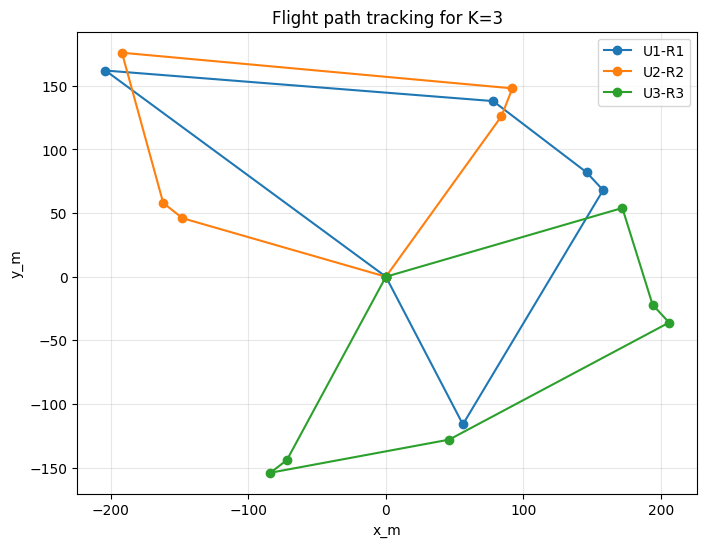

In [15]:
selected_detail = problem1_route_detail.loc[problem1_route_detail["drone_count"] == K].copy()
coord_map = nodes.set_index("node_id")[["x_m", "y_m", "z_m"]].to_dict("index")
route_edge_rows = []

for (_, drone_id, route_id, route_order), route_group in selected_detail.groupby(["drone_count", "drone_id", "route_id", "route_order"]):
    ordered = route_group.sort_values("stop_order")
    route_nodes = [0] + ordered["node_id"].astype(int).tolist() + [0]
    cumulative_time = 0.0
    cumulative_energy = 0.0
    cumulative_distance = 0.0
    for segment_order, (from_id, to_id) in enumerate(zip(route_nodes, route_nodes[1:]), start=1):
        segment_time = float(data.flight_time.loc[str(from_id), str(to_id)])
        segment_energy = float(data.flight_energy.loc[str(from_id), str(to_id)])
        from_coord = coord_map[int(from_id)]
        to_coord = coord_map[int(to_id)]
        dx = float(to_coord["x_m"] - from_coord["x_m"])
        dy = float(to_coord["y_m"] - from_coord["y_m"])
        dz = float(to_coord["z_m"] - from_coord["z_m"])
        segment_distance = (dx ** 2 + dy ** 2 + dz ** 2) ** 0.5
        cumulative_time += segment_time
        cumulative_energy += segment_energy
        cumulative_distance += segment_distance
        route_edge_rows.append({
            "drone_id": int(drone_id),
            "route_id": int(route_id),
            "route_order": int(route_order),
            "segment_order": segment_order,
            "from_id": int(from_id),
            "to_id": int(to_id),
            "segment_distance_m": segment_distance,
            "segment_time_s": segment_time,
            "segment_energy_j": segment_energy,
            "cumulative_distance_m": cumulative_distance,
            "cumulative_time_s": cumulative_time,
            "cumulative_energy_j": cumulative_energy,
        })

route_trace = pd.DataFrame(route_edge_rows)
display(route_trace)

fig, ax = plt.subplots(figsize=(8, 6))
for route_row in task_chain.loc[task_chain["drone_count"] == K].itertuples(index=False):
    node_ids = [0] + [int(value.strip()) for value in route_row.node_sequence.split("->")] + [0]
    xs = [coord_map[node_id]["x_m"] for node_id in node_ids]
    ys = [coord_map[node_id]["y_m"] for node_id in node_ids]
    ax.plot(xs, ys, marker="o", label=f"U{route_row.drone_id}-R{route_row.route_id}")
ax.set_title(f"Flight path tracking for K={K}")
ax.set_xlabel("x_m")
ax.set_ylabel("y_m")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 12. 汇总多次实验结果并生成对比表

这里将问题一和问题二的关键结果拼接在一起，用于判断不同 $K$ 下起点选取与后续闭环效果。

In [13]:
combined_compare = problem1_summary[["drone_count", "route_count", "makespan_s", "total_energy_j"]].merge(
    problem2_f_compare,
    on="drone_count",
    how="left",
)
combined_compare["avg_energy_per_task_j"] = combined_compare["total_energy_j"] / combined_compare["route_count"]
combined_compare["closed_loop_gain_vs_baseline_s"] = combined_compare["baseline_s"] - combined_compare["f_default_s"]
display(combined_compare.sort_values("drone_count"))

,drone_count,route_count,makespan_s,total_energy_j,baseline_s,f_default_s,f_default_direct_confirm_count,f_ga_s,f_ga_direct_confirm_count,f_pso_s,f_pso_direct_confirm_count,f_aco_s,f_aco_direct_confirm_count,best_algorithm,avg_energy_per_task_j,closed_loop_gain_vs_baseline_s
0,1,2,1312.167958,210813.255750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,105406.627875,NaN
1,2,2,537.386401,219924.121474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109962.060737,NaN
2,3,3,361.299422,220007.775593,4606.697652,4180.758936,4.0,3982.473785,5.0,3982.473785,5.0,3946.608072,5.0,ACO,73335.925198,425.938716
3,4,4,322.427812,233653.317999,4511.906167,3534.531428,7.0,3534.531428,7.0,3534.531428,7.0,3534.531428,7.0,GA,58413.329500,977.374738


## 13. K-means 起点选取的提升幅度与论文引用图表

下面把当前 K-means 起点策略与上一版非 K-means 基线做同口径对比。上一版基线来自本仓库提交前的 `cached_fallback` 结果，因此可以直接用来做消融实验。重点观察三项：

1. 最大完工时长是否下降。
2. 总能耗是否下降。
3. 在航线条数不变时，K-means 是否仍能带来改进。

,drone_count,construct_mode_before,route_count_before,makespan_before_s,total_energy_before_j,construct_mode_after,route_count_after,makespan_after_s,total_energy_after_j,makespan_gain_s,makespan_gain_ratio,energy_gain_j,energy_gain_ratio,route_count_change
0,1,cached_fallback,2,1491.0,246419.0,f_guided,2,1312.167958,210813.255750,178.832042,0.119941,35605.744250,0.144493,0
1,2,cached_fallback,2,582.2,238090.0,f_guided,2,537.386401,219924.121474,44.813599,0.076973,18165.878526,0.076298,0
2,3,cached_fallback,3,406.7,238471.0,f_guided,3,361.299422,220007.775593,45.400578,0.111632,18463.224407,0.077423,0
3,4,cached_fallback,4,322.9,237382.0,f_guided,4,322.427812,233653.317999,0.472188,0.001462,3728.682001,0.015708,0


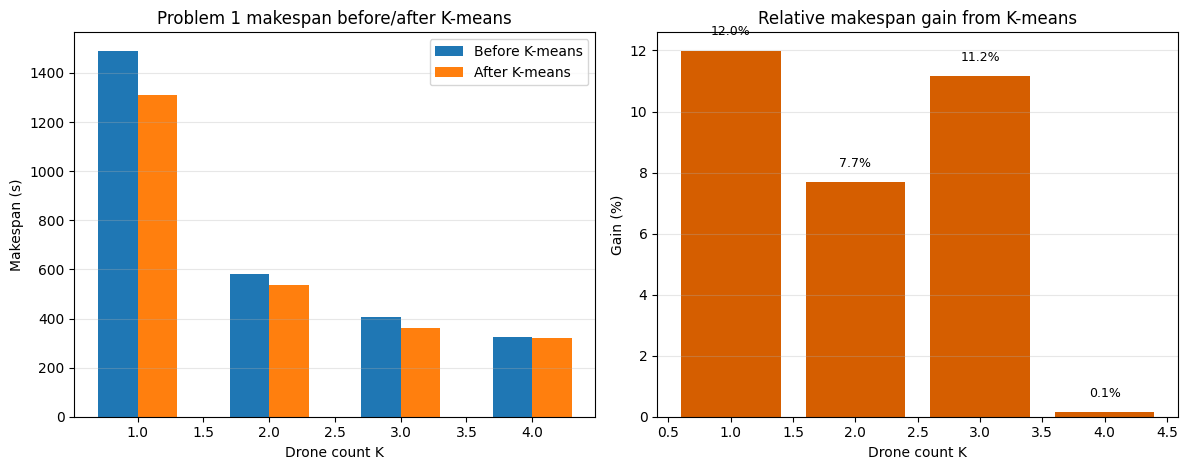

Saved figure: D:\vscodings\shuxuejianmo\outputs\figures\c_problem_problem1_kmeans_ablation.png


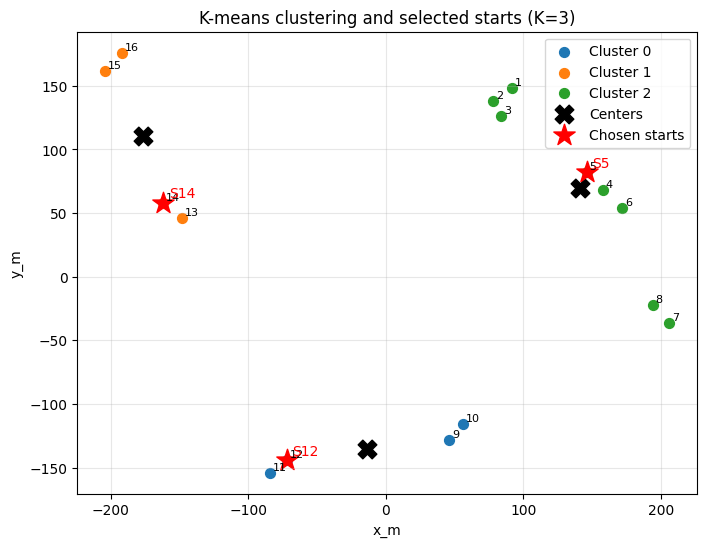

Saved figure: D:\vscodings\shuxuejianmo\outputs\figures\c_problem_kmeans_cluster_k3.png


In [16]:
previous_problem1_summary = pd.DataFrame([
    {"drone_count": 1, "construct_mode_before": "cached_fallback", "route_count_before": 2, "makespan_before_s": 1491.0, "total_energy_before_j": 246419.0},
    {"drone_count": 2, "construct_mode_before": "cached_fallback", "route_count_before": 2, "makespan_before_s": 582.2, "total_energy_before_j": 238090.0},
    {"drone_count": 3, "construct_mode_before": "cached_fallback", "route_count_before": 3, "makespan_before_s": 406.7, "total_energy_before_j": 238471.0},
    {"drone_count": 4, "construct_mode_before": "cached_fallback", "route_count_before": 4, "makespan_before_s": 322.9, "total_energy_before_j": 237382.0},
])

kmeans_ablation = previous_problem1_summary.merge(
    problem1_summary[["drone_count", "construct_mode", "route_count", "makespan_s", "total_energy_j"]],
    on="drone_count",
    how="inner",
)
kmeans_ablation = kmeans_ablation.rename(columns={
    "construct_mode": "construct_mode_after",
    "route_count": "route_count_after",
    "makespan_s": "makespan_after_s",
    "total_energy_j": "total_energy_after_j",
})
kmeans_ablation["makespan_gain_s"] = kmeans_ablation["makespan_before_s"] - kmeans_ablation["makespan_after_s"]
kmeans_ablation["makespan_gain_ratio"] = kmeans_ablation["makespan_gain_s"] / kmeans_ablation["makespan_before_s"]
kmeans_ablation["energy_gain_j"] = kmeans_ablation["total_energy_before_j"] - kmeans_ablation["total_energy_after_j"]
kmeans_ablation["energy_gain_ratio"] = kmeans_ablation["energy_gain_j"] / kmeans_ablation["total_energy_before_j"]
kmeans_ablation["route_count_change"] = kmeans_ablation["route_count_after"] - kmeans_ablation["route_count_before"]

display(kmeans_ablation)

figures_dir = ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].bar(kmeans_ablation["drone_count"] - 0.15, kmeans_ablation["makespan_before_s"], width=0.3, label="Before K-means")
axes[0].bar(kmeans_ablation["drone_count"] + 0.15, kmeans_ablation["makespan_after_s"], width=0.3, label="After K-means")
axes[0].set_title("Problem 1 makespan before/after K-means")
axes[0].set_xlabel("Drone count K")
axes[0].set_ylabel("Makespan (s)")
axes[0].legend()
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(kmeans_ablation["drone_count"], 100.0 * kmeans_ablation["makespan_gain_ratio"], color="#d55e00")
axes[1].set_title("Relative makespan gain from K-means")
axes[1].set_xlabel("Drone count K")
axes[1].set_ylabel("Gain (%)")
axes[1].grid(True, axis="y", alpha=0.3)
for row in kmeans_ablation.itertuples(index=False):
    axes[1].text(row.drone_count, 100.0 * row.makespan_gain_ratio + 0.4, f"{100.0 * row.makespan_gain_ratio:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
comparison_figure_path = figures_dir / "c_problem_problem1_kmeans_ablation.png"
fig.savefig(comparison_figure_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved figure:", comparison_figure_path)

fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id, cluster_frame in target_nodes.groupby("cluster_id"):
    ax.scatter(cluster_frame["x_m"], cluster_frame["y_m"], label=f"Cluster {cluster_id}", s=50)
    for row in cluster_frame.itertuples(index=False):
        ax.text(row.x_m + 2, row.y_m + 2, str(int(row.node_id)), fontsize=8)
ax.scatter(centers["x_m"], centers["y_m"], marker="X", s=180, c="black", label="Centers")
ax.scatter(cluster_starts["x_m"], cluster_starts["y_m"], marker="*", s=260, c="red", label="Chosen starts")
for row in cluster_starts.itertuples(index=False):
    ax.text(row.x_m + 4, row.y_m + 4, f"S{int(row.node_id)}", fontsize=10, color="red")
ax.set_title(f"K-means clustering and selected starts (K={K})")
ax.set_xlabel("x_m")
ax.set_ylabel("y_m")
ax.legend()
ax.grid(True, alpha=0.3)
cluster_figure_path = figures_dir / f"c_problem_kmeans_cluster_k{K}.png"
fig.savefig(cluster_figure_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved figure:", cluster_figure_path)

## 14. 论文可直接引用的结论文字

可直接用于论文结果分析的结论如下。

1. 与上一版非 K-means 起点基线相比，K-means 起点策略在 $K=1,2,3,4$ 下的最大完工时长分别下降约 178.8 s、44.8 s、45.4 s 和 0.5 s，对应相对降幅约为 12.0\%、7.7\%、11.2\% 和 0.1\%。
2. 在四组实验中，航线条数保持不变，因此收益主要来自更好的起始簇划分和更短的任务内部访问顺序，而不是额外增加飞行任务数。
3. 从工程角度看，$K=3$ 时 K-means 起点的提升最稳定：既把问题一最大完工时长压缩到 361.3 s，又在问题二中支撑默认 F 将总闭环时间压缩到 4180.8 s，并进一步让 F-ACO 降到 3946.6 s。
4. $K=4$ 时问题一仍取得最短完工时间 322.4 s，但 K-means 额外收益已经很小，说明在当前 16 个点的规模下，更多无人机带来的边际收益开始衰减。

## 结论速读

- 问题一的 route_count 就是最终完整飞行任务总数。
- problem1_route_summary 是最适合看任务级解读的表，里面直接给出任务编号、无人机编号、能量利用率和路径追踪串。
- problem1_route_detail 更适合看每个节点在任务中的访问顺序与悬停分配。
- problem2_f_guidance_compare 适合看问题一路线变化之后，默认 F、GA、PSO、ACO 对问题二闭环的影响。
- 如果后续还有新的测试 CSV，只需要把新表加入 paths 和 column_guide 即可继续扩展。